In [20]:
from pinballrt.dust import IsotropicDust, HenyeyGreensteinDust, GeneralDust, load, suggest_opacity_sampling
from astropy.modeling import models
import astropy.units as u
import numpy as np

import subprocess

import astropy.io.fits as fits

import tempfile
from multiprocess import Pool

In [36]:
def worker(sample):
    p = sample[0]
    a = sample[1] * u.cm
    Vcarbon = sample[2]
    porosity = sample[3]

    with  tempfile.TemporaryDirectory() as tmpdirname:
        #print(f"/Users/psheehan/pinball-rt/examples/optool/OpacityTool -amax {a.to(u.micron).value} -apow {p} -Vcarbon {Vcarbon} -porosity {porosity} -nlam 1000 -lmax 10000")
        subprocess.run(f"/Users/psheehan/pinball-rt/examples/optool/OpacityTool -amax {a.to(u.micron).value} -apow {p} -Vcarbon {Vcarbon} -porosity {porosity} -nlam 1000 -lmax 10000".split(), capture_output=True, cwd=tmpdirname)

        data = np.loadtxt(tmpdirname+"/particle.dat")

        lam = data[:,0] * u.micron
        kabs = data[:,1]
        ksca = data[:,2]
        g = data[:,3]

        data = fits.open(tmpdirname+"/particle.fits")

        scattering_phase = data[1].data[:,0,:].T

    return lam, kabs, ksca, g, scattering_phase

In [ ]:
samples = suggest_opacity_sampling(600, p_range=(2.5, 4.5), amax_range=(1.*u.micron, 1.*u.cm), n_dust_subspecies=3)

with Pool(6) as pool:
    results = pool.map(worker, samples)
#results = [worker(sample) for sample in samples]

p = samples[:,0]
amax = samples[:,1] * u.cm
Vcarbon = samples[:,2]
porosity = samples[:,3]

lam = results[0][0]  # all results should have the same lam, so we can just take it from the first one
kabs = np.array([r[1] for r in results]) * u.cm**2 / u.g
ksca = np.array([r[2] for r in results]) * u.cm**2 / u.g
g = np.array([r[3] for r in results])
scattering_phase = np.array([r[4] for r in results])

theta = np.linspace(0, 180, scattering_phase.shape[-1]) * u.deg

np.savez("dust_data.npz", 
         kabs=kabs, 
         ksca=ksca, 
         g=g, 
         scattering_phase=scattering_phase, 
         theta=theta, 
         amax=amax, 
         p=p, 
         lam=lam, 
         Vcarbon=Vcarbon, 
         porosity=porosity)

In [ ]:
data = np.load("dust_data.npz")

kabs = data["kabs"] * u.cm**2 / u.g
ksca = data["ksca"] * u.cm**2 / u.g
g = data["g"]
scattering_phase = data["scattering_phase"]
theta = data["theta"] * u.deg
amax = data["amax"] * u.cm
p = data["p"]
lam = data["lam"] * u.micron
Vcarbon = data["Vcarbon"]
porosity = data["porosity"]

In [4]:
"""d = HenyeyGreensteinDust(lam=lam, 
         kabs=kabs, 
         ksca=ksca,
         g=g,
         amax=amax, 
         p=p)"""

p, amax = np.meshgrid(p, amax, indexing='ij')

p = p.flatten()
amax = amax.flatten()

d = GeneralDust(lam=lam,
                kabs=kabs.reshape(-1, lam.size),
                ksca=ksca.reshape(-1, lam.size),
                scattering_phase_function=scattering_phase.reshape(-1, lam.size, theta.size),
                theta=theta.to(u.radian),
                amax=amax,
                p=p)

Warp CUDA warning: Could not find or load the NVIDIA CUDA driver. GPU execution will not be available.


*******************************
random_direction
*******************************


GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/usr/local/python/3.12.1/lib/python3.12/site-packages/pytorch_lightning/trainer/connectors/logger_connector/logger_connector.py:76: Starting from v1.9.0, `tensorboardX` has been removed as a dependency of the `pytorch_lightning` package, due to potential conflicts with other packages in the ML ecosystem. For this reason, `logger=True` will use `CSVLogger` as the default logger, unless the `tensorboard` or `tensorboardX` packages are found. Please `pip install lightning[extra]` or one of them to enable TensorBoard support by default
/usr/local/python/3.12.1/lib/python3.12/site-packages/pytorch_lightning/callbacks/model_checkpoint.py:751: Checkpoint directory /workspaces/pinball-rt/examples/random_direction_lightning_logs exists and is not empty.

  | Name  | Type                 | Params | Mode 
-------------------------------------------------------
0 | model | MultiLayerPerce

Epoch 4: 100%|██████████| 206/206 [00:34<00:00,  5.97it/s, v_num=18, train_loss=0.00748, valid_loss=0.00676]

`Trainer.fit` stopped: `max_epochs=5` reached.


Testing DataLoader 0: 100%|██████████| 29/29 [00:03<00:00,  8.03it/s]
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
       Test metric             DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
        test_loss           0.00679434509947896
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Predicting DataLoader 0: 100%|██████████| 29/29 [00:03<00:00,  7.88it/s]


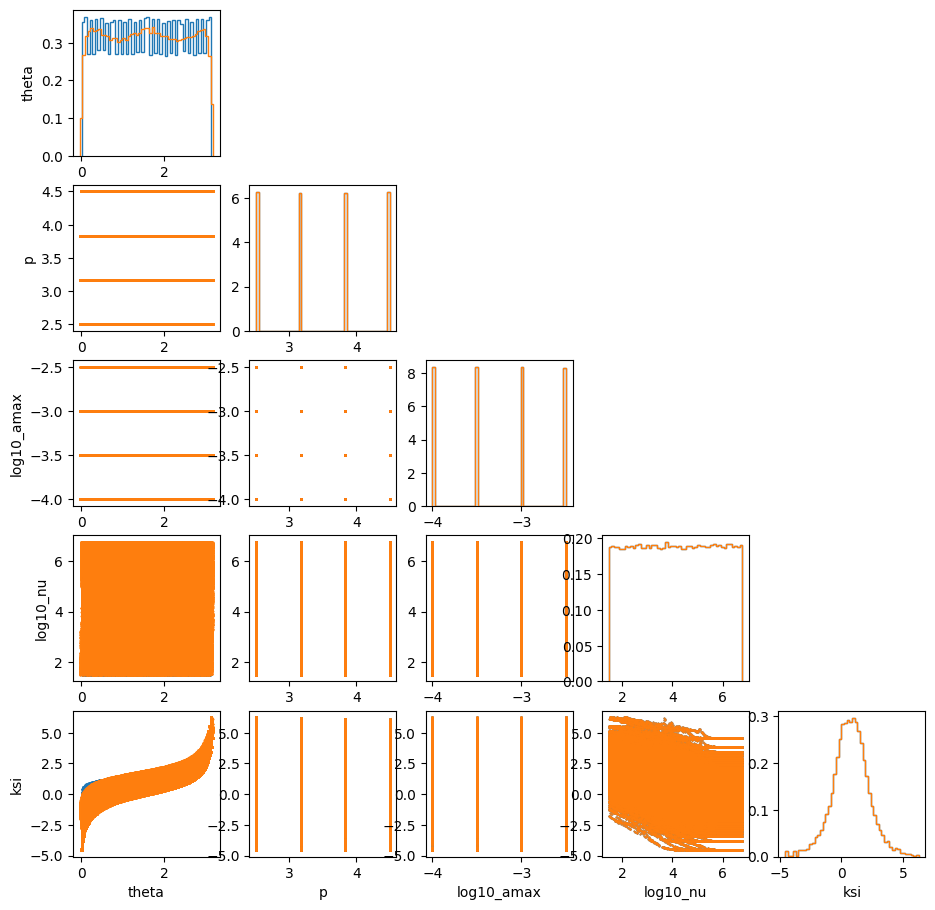

In [4]:
#for model in ["kabs", "ksca", "pmo", "g", "random_nu"]:
#for model in ["kabs", "ksca", "pmo", "scattering_phase_function", "random_nu", "random_direction"]:
#for model in ["scattering_phase_function"]:
for model in ["random_direction"]:
    print("*******************************")
    print(model)
    print("*******************************")

    if model in ["random_direction"]:
        hidden_units = (48,)*6
    elif model in ["random_nu"]:
        hidden_units = (48,)*3
    else:
        hidden_units = (16,)*6
        
    d.learn(model=model, nsamples=1000, hidden_units=hidden_units, overwrite=True)

    d.fit(epochs=5, batch_size=10000)
    d.test_model(plot=True)

In [5]:
d.save("diana.general.dst")
#d.save("diana.hg.dst")

In [ ]:
from schwimmbad import MultiPool
from numpy.random import SeedSequence, seed, randint, set_state
import pandas as pd
from tqdm.auto import tqdm

pool = MultiPool(initializer=tqdm.set_lock, initargs=(tqdm.get_lock(),))

def run_dust_simulation(x):
    s, position = x
    seed(s.generate_state(1)[0])
    df = d.run_dust_simulation(nphotons=1000000, tau_range=(3., 30.), nu_range=(d.nu.min()*10000, d.nu.max()), position=position)
    return df

result = pool.map(run_dust_simulation, list(zip(SeedSequence(12345).spawn(pool.size), range(pool.size))))

df = pd.concat(result, axis=0)

In [7]:
df.to_csv("sim_results.csv")

In [8]:
d.learn(model='ml_step', nsamples=16000000, hidden_units=((128, 128),)*6)

NameError: name 'd' is not defined

In [ ]:
d.fit(epochs=100, batch_size=10000)

In [ ]:
d.test_model(plot=True)

In [ ]:
import astropy.units as u
d.plot_specific_ml_step(tau=1.5, temperature=600*u.K, nu=3e5*u.GHz, nsamples=100000, plot_columns=np.array(["log10_nu"]))

In [ ]:
d.save("amax.dst")